<a href="https://colab.research.google.com/github/nihaar06/Deep_Learning/blob/main/NLP/Tekworks_nlp_assign_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tboyle10/medicaltranscriptions")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'medicaltranscriptions' dataset.
Path to dataset files: /kaggle/input/medicaltranscriptions


In [42]:
import pandas as pd
import numpy as np
df=pd.read_csv(path+"/mtsamples.csv")
df.head()

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [43]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4999 non-null   int64 
 1   description        4999 non-null   object
 2   medical_specialty  4999 non-null   object
 3   sample_name        4999 non-null   object
 4   transcription      4966 non-null   object
 5   keywords           3931 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB


In [44]:
df.dropna(inplace=True)

In [45]:
df.shape

(3898, 6)

<Axes: xlabel='count', ylabel='medical_specialty'>

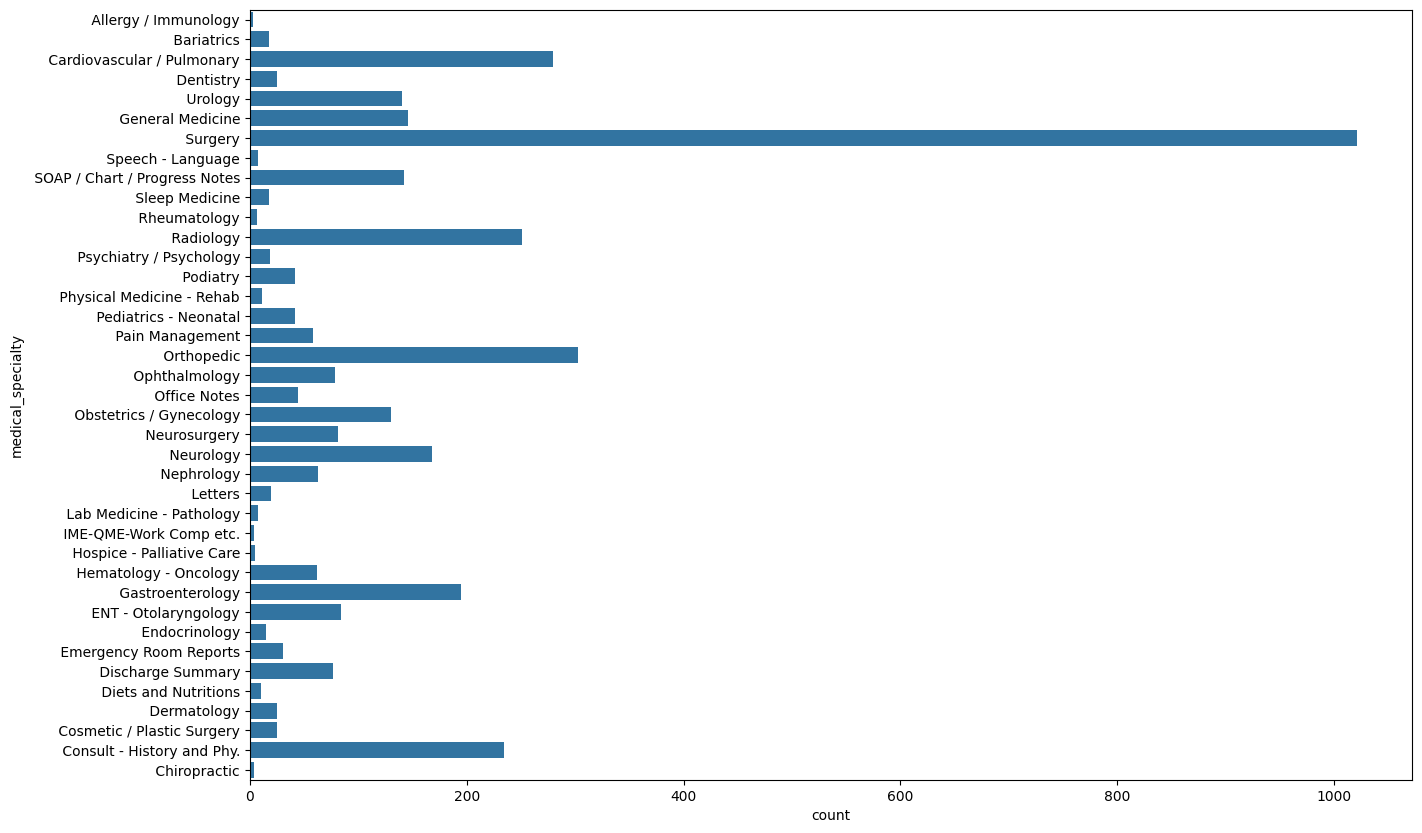

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
sns.countplot(df['medical_specialty'])


In [47]:
from collections import defaultdict
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize
import re # Import re module for regex operations

def clean_text(text):
  text = text.str.lower()
  text = text.str.replace(r"[^\w\s]", "", regex=True)
  return text

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [48]:
cleaned=clean_text(df['transcription'])

In [49]:
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [50]:
filtered=cleaned.apply(lambda x: ' '.join([w for w in x.split() if w not in stop_words]))

In [51]:
dc=defaultdict(int)
for i in filtered:
  if isinstance(i,str):
    for j in i.split():
      dc[j]+=1
sorted_dc=sorted(dc.items(),key=lambda i:i[1],reverse=True)
print("Top 20 Most Common Medical Terms:")
for word, count in sorted_dc[:20]:
    print(f"{word}: {count}")

Top 20 Most Common Medical Terms:
patient: 14759
right: 8323
left: 8053
placed: 6236
procedure: 4535
well: 4488
normal: 4237
using: 3449
history: 3222
incision: 3221
used: 3067
removed: 2990
performed: 2883
skin: 2847
noted: 2836
room: 2762
pain: 2748
diagnosis: 2664
time: 2598
also: 2577


In [58]:
from tensorflow.keras.layers import Input,Embedding,Dense,MultiHeadAttention
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer=Tokenizer()
tokenizer.fit_on_texts(filtered)
seq=tokenizer.texts_to_sequences(filtered)
pad_seq=pad_sequences(seq,maxlen=len(tokenizer.word_index)+1,padding='post')

pad_seq.shape

(3898, 32384)

In [59]:
input=Input(shape=(None,))
emb=Embedding(input_dim=len(tokenizer.word_index)+1,output_dim=100)(input)
dense=Dense(1,activation='sigmoid')(emb)
model=Model(inputs=input,outputs=dense)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 100)      │     3,238,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 1)        │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,238,501 (12.35 MB)

 Trainable params: 3,238,501 (12.35 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

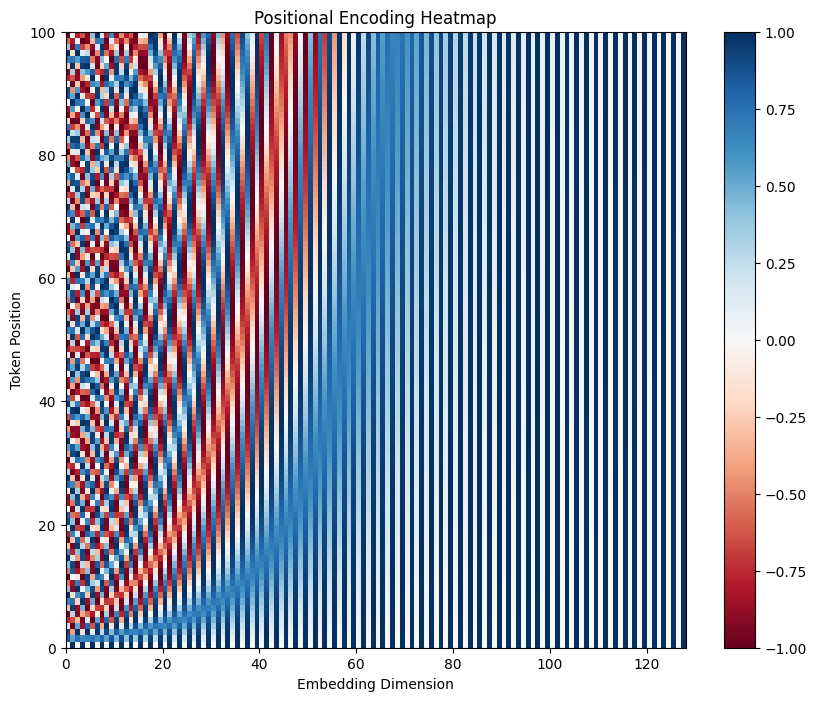

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def get_positional_encoding(max_seq_len, d_model):
    arg = np.arange(max_seq_len)[:, np.newaxis] / np.power(10000, (2 * (np.arange(d_model)[np.newaxis, :] // 2)) / np.float32(d_model))
    pos_encoding = np.zeros((max_seq_len, d_model))
    pos_encoding[:, 0::2] = np.sin(arg[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(arg[:, 1::2])
    return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

# Visualize Positional Encoding
pos_enc = get_positional_encoding(100, 128)
plt.figure(figsize=(10, 8))
plt.pcolormesh(pos_enc[0], cmap='RdBu')
plt.xlabel('Embedding Dimension')
plt.ylabel('Token Position')
plt.colorbar()
plt.title('Positional Encoding Heatmap')
plt.show()

In [63]:
from tensorflow.keras.layers import LayerNormalization, GlobalAveragePooling1D

# Define Model Parameters
max_len = 500 # Truncating for memory efficiency during attention
vocab_size = len(tokenizer.word_index) + 1
embed_dim = 128
num_heads = 4
pad_seq_trunc = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

# Build Self-Attention Model
inputs = Input(shape=(max_len,))
x = Embedding(input_dim=vocab_size, output_dim=embed_dim)(inputs)
x += get_positional_encoding(max_len, embed_dim)
x = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
x = LayerNormalization()(x)
x = GlobalAveragePooling1D()(x)
outputs = Dense(len(df['medical_specialty'].unique()), activation='softmax')(x)

attn_model = Model(inputs=inputs, outputs=outputs)
attn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
attn_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 500)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 500, 128)  │  4,145,152 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 500, 128)  │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 500, 128)  │    263,808 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 500, 128)  │        256 │ multi_head_atten… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 39)        │      5,031 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,414,247 (16.84 MB)

 Trainable params: 4,414,247 (16.84 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

# Prepare labels
le = LabelEncoder()
y = le.fit_transform(df['medical_specialty'])

print('Training the attention model...')
attn_model.fit(pad_seq_trunc, y, epochs=5, batch_size=32, validation_split=0.2, verbose=1)

def get_diagnostic_importance(text):
    # Tokenize and pad the input text
    sequence = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(sequence, maxlen=max_len, padding='post', truncating='post')

    attention_layer = attn_model.layers[3]
    embedding_output = attn_model.layers[2](attn_model.layers[1](attn_model.layers[0](padded)))

    _, weights = attention_layer(embedding_output, embedding_output, return_attention_scores=True)

    # Process weights: average across heads
    avg_weights = tf.reduce_mean(weights, axis=1)[0]
    importance_scores = tf.reduce_sum(avg_weights, axis=0).numpy()

    # Map weights back to words
    words = text.split()[:max_len]
    importance_map = []
    for i, word in enumerate(words):
        if i < len(importance_scores):
            importance_map.append((word, float(importance_scores[i])))

    return sorted(importance_map, key=lambda x: x[1], reverse=True)[:10]

In [ ]:
!pip install -q gradio
import gradio as gr

def healthcare_dashboard(report_text):
    # Cleaning
    clean_report = report_text.lower().replace(r'[^\w\s]', '')

    # Prediction
    sequence = tokenizer.texts_to_sequences([clean_report])
    padded = pad_sequences(sequence, maxlen=max_len, padding='post', truncating='post')
    preds = attn_model.predict(padded)
    class_idx = np.argmax(preds[0])
    confidence = float(np.max(preds[0]))
    specialty = le.inverse_transform([class_idx])[0]

    # Importance Analysis
    importance = get_diagnostic_importance(clean_report)
    importance_text = "\n".join([f'{w}: {s:.4f}' for w, s in importance])

    return specialty, f'{confidence:.2%}', importance_text

interface = gr.Interface(
    fn=healthcare_dashboard,
    inputs=gr.Textbox(lines=10, placeholder='Paste medical report here...'),
    outputs=[gr.Label(label='Predicted Specialty'), gr.Textbox(label='Confidence Score'), gr.Textbox(label='Top Influential Terms')],
    title='Explainable Healthcare NLP Dashboard'
)

interface.launch(share=True)

In [ ]:
import pandas as pd
import numpy as np

# Prepare labels for training
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['medical_specialty'])

attn_model.fit(pad_seq_trunc, y, epochs=3, batch_size=32, validation_split=0.2)

def get_diagnostic_importance(sample_idx):
    sample_seq = pad_seq_trunc[sample_idx:sample_idx+1]

    # Create a sub-model to extract attention weights
    # MultiHeadAttention is the 4th layer (index 3)
    attention_layer = attn_model.layers[3]

    # Extract attention output and weights
    _, weights = attention_layer(attn_model.layers[2](attn_model.layers[1](attn_model.layers[0](sample_seq))),
                                attn_model.layers[2](attn_model.layers[1](attn_model.layers[0](sample_seq))),
                                return_attention_scores=True)

    # Average across heads and find top tokens
    avg_weights = tf.reduce_mean(weights, axis=1)[0]
    token_importance = tf.reduce_sum(avg_weights, axis=0)

    # Map back to words
    reverse_word_index = {v: k for k, v in tokenizer.word_index.items()}
    tokens = sample_seq[0]

    importance_list = []
    for i, token in enumerate(tokens):
        if token != 0: # Ignore padding
            importance_list.append((reverse_word_index.get(token, "UNK"), token_importance[i].numpy()))

    # Sort by importance
    importance_list = sorted(importance_list, key=lambda x: x[1], reverse=True)
    return importance_list[:10]

# Analyze importance for the first sample
print("Top Diagnostic Words for Sample 0:")
print(get_diagnostic_importance(0))

Epoch 1/3
15/98 ━━━━━━━━━━━━━━━━━━━━ 4:25 3s/step - accuracy: 0.1806 - loss: 3.5825